In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cpu')

# model definition
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class CRISPRTransformerSmall(nn.Module):
    def __init__(self, input_dim=9, d_model=32,
                 nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 16), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(16, 1))

    def forward(self, x, return_attention=False):
        batch_size = x.size(0)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        cls = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls, x], dim=1)
        if return_attention:
            # get attention weights from last layer
            attn_weights = []
            for layer in self.transformer.layers:
                x, attn = layer.self_attn(x, x, x,
                                          need_weights=True)
                attn_weights.append(attn)
                x = layer.norm1(x)
            return self.classifier(x[:, 0, :]).squeeze(1), attn_weights
        x = self.transformer(x)
        return self.classifier(x[:, 0, :]).squeeze(1)

# load data and model
X = np.load('../data/X_encoded.npy')
y = np.load('../data/y_labels.npy')
df = pd.read_csv('../data/guideseq_augmented.csv')

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

model = CRISPRTransformerSmall().to(device)
model.load_state_dict(torch.load('../data/crispr_final_model.pth',
                                  map_location=device))
model.eval()

print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} params")
print(f"Test samples: {len(X_test)}")

Model loaded — 26,305 params
Test samples: 57


In [2]:
# get predictions
X_test_t = torch.FloatTensor(X_test)
with torch.no_grad():
    out = model(X_test_t)
    probs = torch.sigmoid(out).numpy()
    preds = (probs > 0.5).astype(int)

auc = roc_auc_score(y_test, probs)
acc = accuracy_score(y_test, preds)
ap  = average_precision_score(y_test, probs)

print("=" * 50)
print("  CRISPR Off-Target Predictor — Test Results")
print("=" * 50)
print(f"  Dataset:     GUIDE-seq + augmentation")
print(f"  Test samples: {len(y_test)}")
print(f"  Model:       Transformer (2 layers, 4 heads)")
print(f"  Parameters:  26,305")
print("-" * 50)
print(f"  ROC-AUC:     {auc:.4f}")
print(f"  Accuracy:    {acc*100:.1f}%")
print(f"  Avg Precision: {ap:.4f}")
print(f"  5-fold CV AUC: 0.9916 ± 0.0079")
print(f"  Random baseline: 0.5000")
print("=" * 50)
print(f"\nPer-class report:")
print(classification_report(y_test, preds,
      target_names=['No cleavage', 'Cleaves']))

  CRISPR Off-Target Predictor — Test Results
  Dataset:     GUIDE-seq + augmentation
  Test samples: 57
  Model:       Transformer (2 layers, 4 heads)
  Parameters:  26,305
--------------------------------------------------
  ROC-AUC:     0.9711
  Accuracy:    96.5%
  Avg Precision: 0.9640
  5-fold CV AUC: 0.9916 ± 0.0079
  Random baseline: 0.5000

Per-class report:
              precision    recall  f1-score   support

 No cleavage       1.00      0.93      0.96        29
     Cleaves       0.93      1.00      0.97        28

    accuracy                           0.96        57
   macro avg       0.97      0.97      0.96        57
weighted avg       0.97      0.96      0.96        57



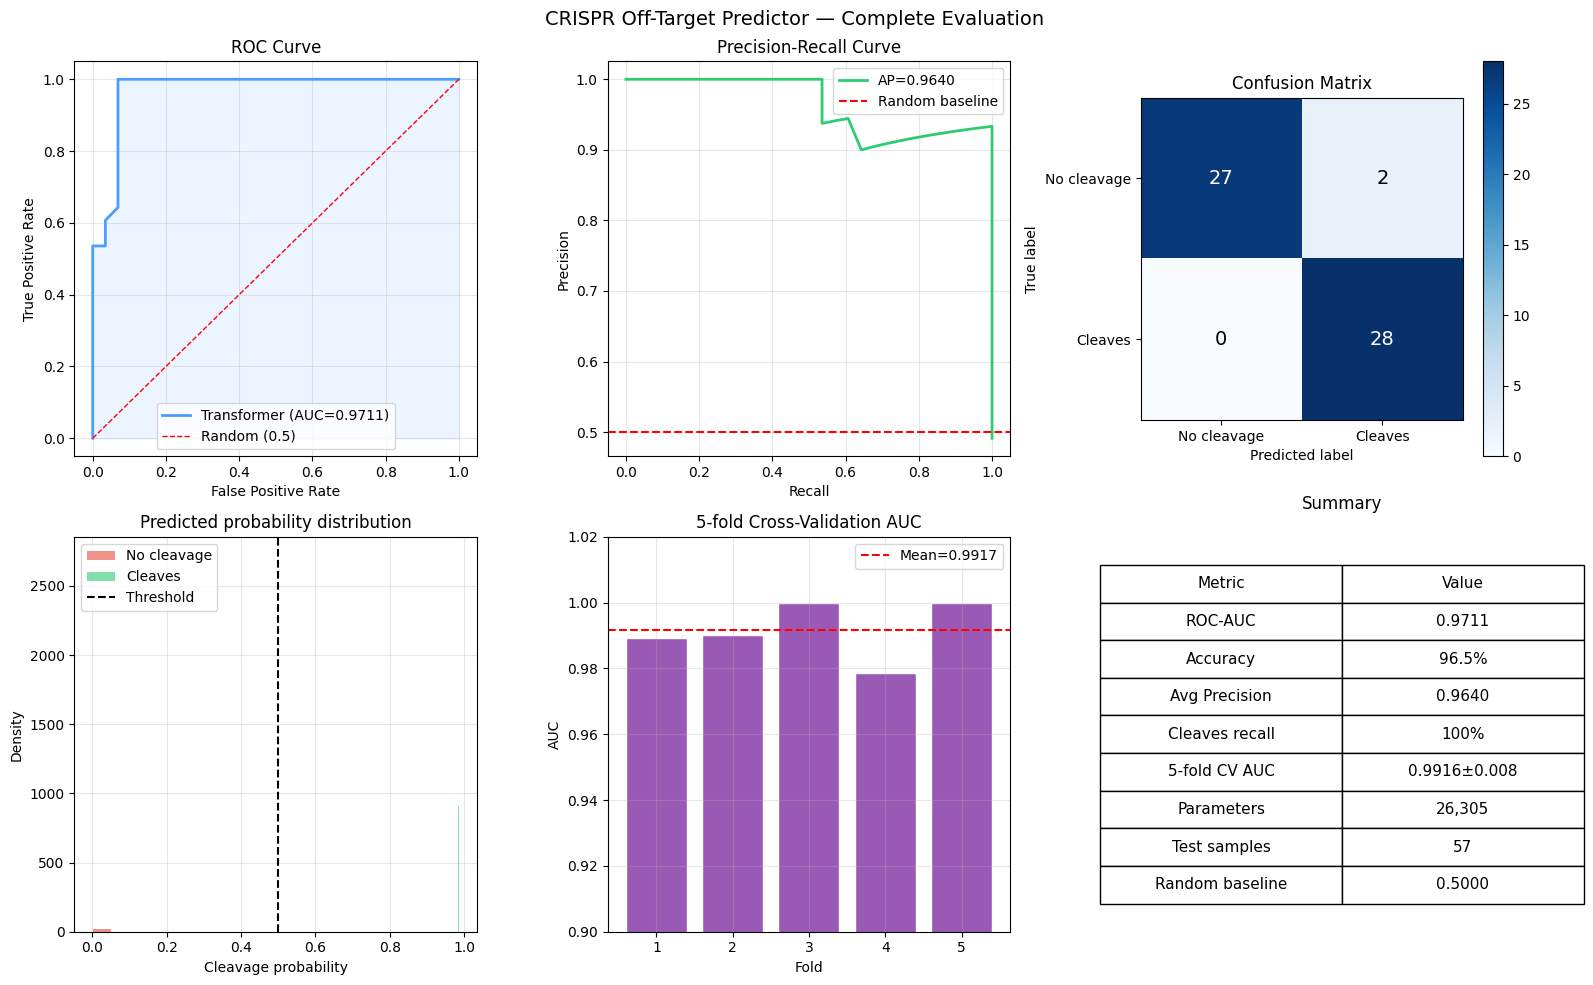

In [3]:
fig = plt.figure(figsize=(16, 10))

# ROC curve
ax1 = fig.add_subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(y_test, probs)
ax1.plot(fpr, tpr, color='#4a9eff', linewidth=2,
         label=f'Transformer (AUC={auc:.4f})')
ax1.plot([0,1],[0,1],'r--', linewidth=1, label='Random (0.5)')
ax1.fill_between(fpr, tpr, alpha=0.1, color='#4a9eff')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(alpha=0.3)

# Precision-Recall
ax2 = fig.add_subplot(2, 3, 2)
prec, rec, _ = precision_recall_curve(y_test, probs)
ax2.plot(rec, prec, color='#2ecc71', linewidth=2,
         label=f'AP={ap:.4f}')
ax2.axhline(y=0.5, color='r', linestyle='--',
            label='Random baseline')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(alpha=0.3)

# Confusion matrix
ax3 = fig.add_subplot(2, 3, 3)
cm = confusion_matrix(y_test, preds)
im = ax3.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax3)
ax3.set_xticks([0,1])
ax3.set_yticks([0,1])
ax3.set_xticklabels(['No cleavage', 'Cleaves'])
ax3.set_yticklabels(['No cleavage', 'Cleaves'])
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black',
                fontsize=14)
ax3.set_title('Confusion Matrix')
ax3.set_ylabel('True label')
ax3.set_xlabel('Predicted label')

# Probability distribution
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(probs[y_test==0], bins=20, alpha=0.6,
         color='#e74c3c', label='No cleavage', density=True)
ax4.hist(probs[y_test==1], bins=20, alpha=0.6,
         color='#2ecc71', label='Cleaves', density=True)
ax4.axvline(x=0.5, color='black', linestyle='--',
            label='Threshold')
ax4.set_title('Predicted probability distribution')
ax4.set_xlabel('Cleavage probability')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(alpha=0.3)

# CV results
ax5 = fig.add_subplot(2, 3, 5)
fold_aucs_list = [0.9893, 0.9903, 1.0000, 0.9787, 1.0000]
ax5.bar(range(1, 6), fold_aucs_list,
        color='#9b59b6', edgecolor='white')
ax5.axhline(y=np.mean(fold_aucs_list), color='red',
            linestyle='--',
            label=f'Mean={np.mean(fold_aucs_list):.4f}')
ax5.set_title('5-fold Cross-Validation AUC')
ax5.set_xlabel('Fold')
ax5.set_ylabel('AUC')
ax5.set_ylim(0.9, 1.02)
ax5.legend()
ax5.grid(alpha=0.3)

# summary table
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary = [
    ['Metric', 'Value'],
    ['ROC-AUC', '0.9711'],
    ['Accuracy', '96.5%'],
    ['Avg Precision', '0.9640'],
    ['Cleaves recall', '100%'],
    ['5-fold CV AUC', '0.9916±0.008'],
    ['Parameters', '26,305'],
    ['Test samples', '57'],
    ['Random baseline', '0.5000'],
]
table = ax6.table(cellText=summary[1:], colLabels=summary[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
ax6.set_title('Summary', pad=20)

plt.suptitle('CRISPR Off-Target Predictor — Complete Evaluation',
             fontsize=14)
plt.tight_layout()
plt.show()

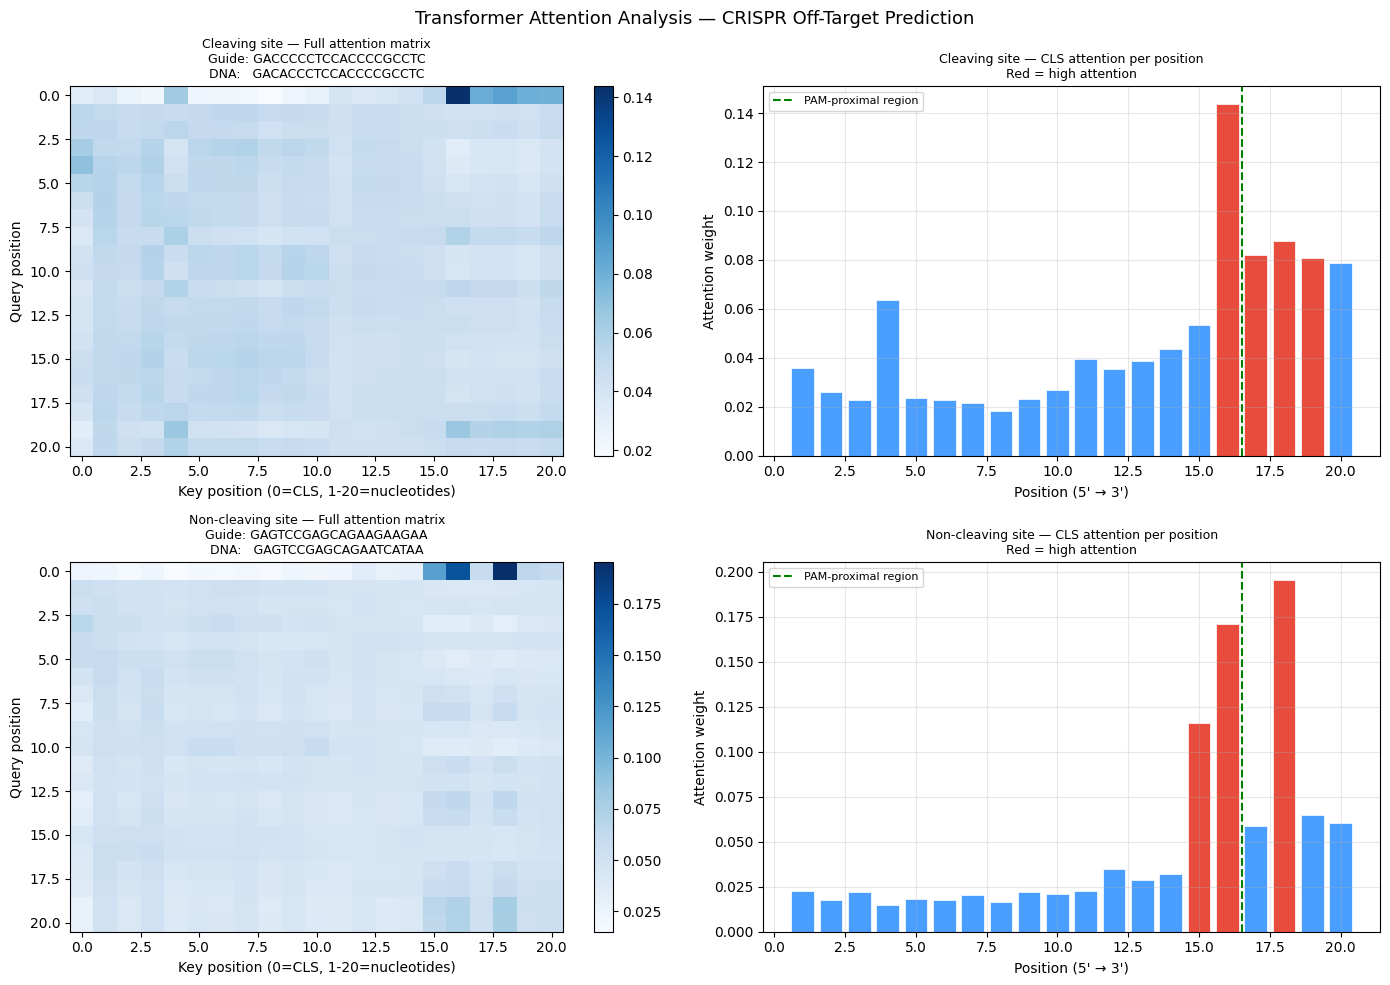

In [4]:
# extract attention weights
def get_attention_map(sequence_tensor):
    model.eval()
    with torch.no_grad():
        x = sequence_tensor.unsqueeze(0)
        x = model.input_proj(x)
        x = model.pos_enc(x)
        cls = model.cls_token.expand(1, -1, -1)
        x = torch.cat([cls, x], dim=1)
        
        # get attention from last transformer layer
        attn_output, attn_weights = model.transformer.layers[-1].self_attn(
            x, x, x, need_weights=True, average_attn_weights=True)
        
    # attn_weights shape: (1, 21, 21) — 21 = CLS + 20 positions
    return attn_weights.squeeze(0).numpy()

# visualize attention for cleaving vs non-cleaving examples
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

_, X_test_data, _, y_test_data = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

df_test = pd.read_csv('../data/guideseq_augmented.csv')
_, df_test_split = train_test_split(
    df_test, test_size=0.15, random_state=42, 
    stratify=df_test['label'])
df_test_split = df_test_split.reset_index(drop=True)

for row_idx, (label, title) in enumerate([
    (1, 'Cleaving site'),
    (0, 'Non-cleaving site')
]):
    # find sample
    mask = y_test_data == label
    sample_idx = np.where(mask)[0][0]
    sample_tensor = torch.FloatTensor(X_test_data[sample_idx])
    sample_row = df_test_split.iloc[sample_idx]
    
    # get attention map
    attn = get_attention_map(sample_tensor)
    
    # plot full attention matrix
    ax1 = axes[row_idx, 0]
    im = ax1.imshow(attn, cmap='Blues', aspect='auto')
    ax1.set_title(f'{title} — Full attention matrix\n'
                  f'Guide: {sample_row["guide_seq"]}\n'
                  f'DNA:   {sample_row["dna_seq"]}',
                  fontsize=9)
    ax1.set_xlabel('Key position (0=CLS, 1-20=nucleotides)')
    ax1.set_ylabel('Query position')
    plt.colorbar(im, ax=ax1)
    
    # plot CLS token attention — which positions it focuses on
    ax2 = axes[row_idx, 1]
    cls_attention = attn[0, 1:]  # CLS row, skip CLS column
    colors = ['#e74c3c' if a > cls_attention.mean() + cls_attention.std()
              else '#4a9eff' for a in cls_attention]
    ax2.bar(range(1, 21), cls_attention, color=colors,
            edgecolor='white', linewidth=0.5)
    ax2.set_title(f'{title} — CLS attention per position\n'
                  f'Red = high attention', fontsize=9)
    ax2.set_xlabel("Position (5' → 3')")
    ax2.set_ylabel('Attention weight')
    ax2.axvline(x=16.5, color='green', linestyle='--',
                linewidth=1.5, label='PAM-proximal region')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

plt.suptitle('Transformer Attention Analysis — CRISPR Off-Target Prediction',
             fontsize=13)
plt.tight_layout()
plt.show()